# JAEE — Table I, II, III dan Fig. 4: Estimasi 5 parameter fisiologis (LOSO)

Notebook ini menghasilkan: **Table I** (kohort), **Table II** (model terpilih dan metrik LOSO), **Table III** (studi kasus S010 vs lab Parahita), dan **Fig. 4** (prediksi vs referensi + akurasi).

Skema validasi: Leave-One-Subject-Out pada 11 subjek (1 rekaman/subjek), sama dengan pipeline produksi `api.vital_model_training.train_all`. Akurasi (%) = 100 − MAPE. Sel terakhir (suplemen) menjalankan LOSO bersarang sebagai bahan jawaban bila reviewer bertanya; hasilnya tidak dipakai di artikel.

In [1]:
import warnings, sys, json, pathlib
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Semua gambar/JSON artikel JAEE disimpan di sini (relatif terhadap folder model/)
FIG = pathlib.Path("../figures-jaee")
FIG.mkdir(exist_ok=True)

# Gaya sesuai template JAEE: Times New Roman 8 pt, kolom 3,5 in / halaman 7,16 in, 300 dpi
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8, "legend.fontsize": 7,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "figure.dpi": 110, "savefig.dpi": 300,
    "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
    "mathtext.fontset": "stix",
})
COL_W, PAGE_W = 3.5, 7.16

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")


In [2]:
from api.vital_model_training import records_to_dataframe, train_all, FEATURES_T, TARGETS_T
from sklearn.metrics import mean_absolute_error

# Himpunan kandidat model = yang dilaporkan di Laporan Kemajuan: SVR (kernel linear dan RBF) dan XGBoost.
# (MLP sudah dibandingkan pada tahap awal dan kalah pada semua parameter; lihat Lampiran 1.5 laporan.)
import api.vital_model_training as VM
_orig_kandidat = VM._model_kandidat
VM._model_kandidat = lambda kw: {k: v for k, v in _orig_kandidat(kw).items() if k.startswith(("SVR", "XGBoost"))}

raw = pd.read_csv("../kalibrasi_semua.csv")
df = records_to_dataframe(raw.to_dict("records"))
ORDER = ["sistolik_mmhg", "diastolik_mmhg", "gula_darah_mg_dl", "kolesterol_mg_dl", "asam_urat_mg_dl"]
LABEL = {"sistolik_mmhg": "SBP (mmHg)", "diastolik_mmhg": "DBP (mmHg)", "gula_darah_mg_dl": "Glucose (mg/dL)",
         "kolesterol_mg_dl": "Cholesterol (mg/dL)", "asam_urat_mg_dl": "Uric acid (mg/dL)"}
SHORT = {"sistolik_mmhg": "SBP", "diastolik_mmhg": "DBP", "gula_darah_mg_dl": "Glucose",
         "kolesterol_mg_dl": "Cholesterol", "asam_urat_mg_dl": "Uric acid"}
def J(o):
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.integer): return int(o)
    if isinstance(o, np.ndarray): return o.tolist()
    return str(o)

# ---------- TABLE I: karakteristik kohort ----------
def ms(x, d=1):
    return f"{x.mean():.{d}f} ± {x.std(ddof=1):.{d}f} ({x.min():.{d}f}–{x.max():.{d}f})"

tabel1 = [("Subjects, n", str(len(raw))),
          ("Age (years), mean ± SD (range)", ms(raw.age_years, 1)),
          ("Sex, male / female", f"{(raw.gender == 'L').sum()} / {(raw.gender == 'P').sum()}"),
          ("Sampling condition", ", ".join(sorted(raw.kondisi.unique())) + " (non-fasting)"),
          ("Heart rate, oximeter (bpm)", ms(raw.oksimeter_bpm, 1))]
cv_pct = {}
for t in ORDER:
    d = 0 if t != "asam_urat_mg_dl" else 1
    tabel1.append((LABEL[t] + ", reference device", ms(raw[t], d)))
    cv_pct[t] = float(raw[t].std(ddof=1) / raw[t].mean() * 100)
for k, v in tabel1: print(f"{k:45s} {v}")
print("CV (%):", {SHORT[k]: round(v, 1) for k, v in cv_pct.items()})

Subjects, n                                   11
Age (years), mean ± SD (range)                65.0 ± 16.7 (20.0–80.0)
Sex, male / female                            5 / 6
Sampling condition                            sewaktu (non-fasting)
Heart rate, oximeter (bpm)                    80.3 ± 13.0 (54.0–102.0)
SBP (mmHg), reference device                  147 ± 16 (121–173)
DBP (mmHg), reference device                  83 ± 12 (56–102)
Glucose (mg/dL), reference device             141 ± 35 (94–183)
Cholesterol (mg/dL), reference device         232 ± 37 (151–269)
Uric acid (mg/dL), reference device           5.3 ± 1.0 (3.7–7.2)
CV (%): {'SBP': 11.2, 'DBP': 14.9, 'Glucose': 25.0, 'Cholesterol': 16.0, 'Uric acid': 18.9}


In [3]:
# ---------- Model terpilih pipeline produksi + prediksi LOSO per subjek ----------
# Pipeline produksi (api.vital_model_training.train_all) memilih, untuk tiap parameter, kombinasi model+fitur
# dengan skor validasi LOSO terbaik (LOO = LOSO karena 1 rekaman/subjek), lalu melaporkan prediksi LOSO-nya.
_, met = train_all(df)
loso = {}
sel = {}
for t in ORDER:
    yt, yp = np.array(met[t]["cv_y_true"], float), np.array(met[t]["cv_y_pred"], float)
    assert np.allclose(yt, df[t].values.astype(float)), "urutan subjek tidak cocok"
    loso[t] = dict(subject=list(df.subject_id), y=yt.tolist(), pred=yp.tolist())
    sel[t] = dict(model=met[t]["model_name"], features=met[t]["feature_set_name"])
print(pd.DataFrame(sel).T)

                                 model             features
sistolik_mmhg             SVR (linear)      Penuh (7 fitur)
diastolik_mmhg            SVR (linear)      Penuh (7 fitur)
gula_darah_mg_dl  XGBoost (reg. ketat)  Minimal (usia saja)
kolesterol_mg_dl          SVR (linear)  Minimal (usia saja)
asam_urat_mg_dl              SVR (rbf)  Minimal (usia saja)


In [4]:
def reg_metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    e = y - p
    return dict(mae=float(np.mean(np.abs(e))), rmse=float(np.sqrt(np.mean(e ** 2))),
                mape=float(np.mean(np.abs(e) / np.maximum(np.abs(y), 1e-9)) * 100),
                acc=float(100 - np.mean(np.abs(e) / np.maximum(np.abs(y), 1e-9)) * 100))

out, rows = {}, []
for t in ORDER:
    d = loso[t]
    m = reg_metrics(d["y"], d["pred"])
    assert abs(m["acc"] - met[t]["accuracy_pct"]) < 0.1, "akurasi tidak sama dengan pipeline"   # prediksi tersimpan dibulatkan 2 desimal
    m["acc"] = float(met[t]["accuracy_pct"])                                                       # angka resmi pipeline
    out[t] = dict(label=LABEL[t], n=len(d["y"]), model=sel[t]["model"], features=sel[t]["features"], **m)
    rows.append([SHORT[t], sel[t]["model"], sel[t]["features"], m["mae"], m["rmse"], m["acc"]])
tab2 = pd.DataFrame(rows, columns=["Parameter", "Selected model", "Feature set", "MAE", "RMSE", "Accuracy (%)"])
print(tab2.round(2).to_string(index=False))

  Parameter       Selected model         Feature set   MAE  RMSE  Accuracy (%)
        SBP         SVR (linear)     Penuh (7 fitur) 13.18 16.06         90.98
        DBP         SVR (linear)     Penuh (7 fitur)  6.09  9.61         91.37
    Glucose XGBoost (reg. ketat) Minimal (usia saja) 29.36 35.57         76.22
Cholesterol         SVR (linear) Minimal (usia saja) 30.44 37.39         85.14
  Uric acid            SVR (rbf) Minimal (usia saja)  0.75  0.96         86.20


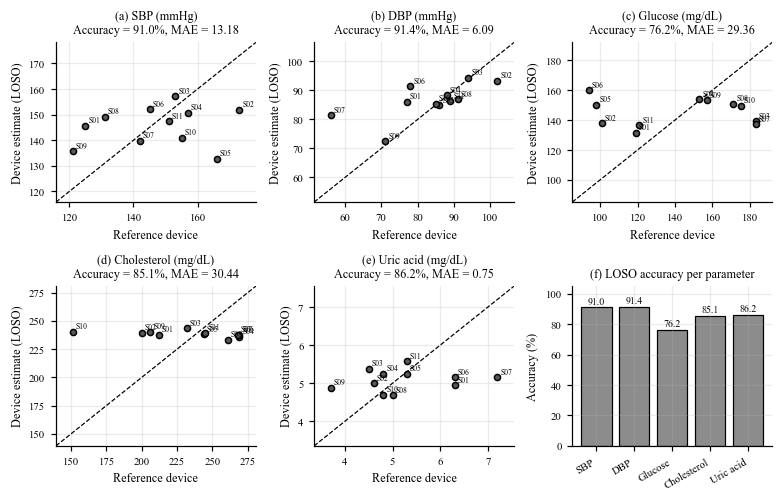

In [5]:
# ---------- Fig. 4: prediksi LOSO vs. nilai referensi ----------
fig, axes = plt.subplots(2, 3, figsize=(PAGE_W, 4.6))
letters = "abcde"
for k, t in enumerate(ORDER):
    ax = axes.flat[k]
    d = loso[t]
    y, p = np.array(d["y"]), np.array(d["pred"])
    lo, hi = min(y.min(), p.min()), max(y.max(), p.max())
    pad = 0.10 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=.8)
    ax.plot(y, p, "o", ms=4, mfc="0.35", mec="black")
    for s, xi, yi in zip(d["subject"], y, p):                       # label subjek, seperti gambar laporan
        ax.annotate(s.replace("S0", "S"), (xi, yi), fontsize=5, xytext=(2, 2), textcoords="offset points")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("Reference device"); ax.set_ylabel("Device estimate (LOSO)")
    m = out[t]
    ax.set_title(f"({letters[k]}) {LABEL[t]}\nAccuracy = {m['acc']:.1f}%, MAE = {m['mae']:.2f}")
ax = axes.flat[5]
accs = [out[t]["acc"] for t in ORDER]
bars = ax.bar(range(5), accs, color="0.55", edgecolor="black", lw=.8)
for b_, v in zip(bars, accs):
    ax.text(b_.get_x() + b_.get_width() / 2, v + 1, f"{v:.1f}", ha="center", va="bottom", fontsize=6.5)
ax.set_ylim(0, 105)
ax.set_xticks(range(5)); ax.set_xticklabels([SHORT[t] for t in ORDER], rotation=30, ha="right")
ax.set_ylabel("Accuracy (%)"); ax.set_title("(f) LOSO accuracy per parameter")
fig.tight_layout()
save(fig, "fig4_estimasi_vital")
plt.show()

In [6]:
# ---------- TABLE III: studi kasus S010 vs. hasil laboratorium Klinik Parahita ----------
# Nilai lab dari lembar hasil No. Lab 2326UG0006 (sampel 07 Sep 2026, tanpa puasa).
LAB = {"sistolik_mmhg": 150.0, "diastolik_mmhg": 80.0, "gula_darah_mg_dl": 178.0,
       "kolesterol_mg_dl": 154.0, "asam_urat_mg_dl": 4.6}
rows, case = [], {}
for t in ORDER:
    j = loso[t]["subject"].index("S010")
    est = loso[t]["pred"][j]                                    # prediksi LOSO (S010 tidak ikut latih)
    poct = loso[t]["y"][j]                                      # alat referensi saat sesi (POCT/tensimeter)
    lab = LAB[t]
    rel_lab = 100 - abs(est - lab) / lab * 100
    rel_poct = 100 - abs(poct - lab) / lab * 100
    case[t] = dict(lab=lab, poct=poct, est=est, abs_err_est=abs(est - lab), acc_est=rel_lab,
                   abs_err_poct=abs(poct - lab), acc_poct=rel_poct)
    rows.append([LABEL[t], lab, poct, round(est, 1), round(abs(est - lab), 1), round(rel_lab, 1),
                 round(abs(poct - lab), 1), round(rel_poct, 1)])
tab3 = pd.DataFrame(rows, columns=["Parameter", "Laboratory", "Reference device", "Proposed device (LOSO)",
                                   "|Err| vs lab", "Acc% vs lab", "|Device - lab|", "Device acc%"])
print(tab3.to_string(index=False))

          Parameter  Laboratory  Reference device  Proposed device (LOSO)  |Err| vs lab  Acc% vs lab  |Device - lab|  Device acc%
         SBP (mmHg)       150.0             155.0                   141.0           9.0         94.0             5.0         96.7
         DBP (mmHg)        80.0              85.0                    85.4           5.4         93.2             5.0         93.8
    Glucose (mg/dL)       178.0             175.0                   149.4          28.6         84.0             3.0         98.3
Cholesterol (mg/dL)       154.0             151.0                   240.5          86.5         43.9             3.0         98.1
  Uric acid (mg/dL)         4.6               4.8                     4.7           0.1         97.8             0.2         95.7


In [7]:
# ---------- Kesalahan penurunan flag hipertensi dari estimasi tekanan darah ----------
# Flag hipertensi model stroke = SBP >= 140 atau DBP >= 90 (lihat api/profile_utils.derive_hypertension).
subj = loso["sistolik_mmhg"]["subject"]
sbp_y, sbp_p = np.array(loso["sistolik_mmhg"]["y"]), np.array(loso["sistolik_mmhg"]["pred"])
dbp_y, dbp_p = np.array(loso["diastolik_mmhg"]["y"]), np.array(loso["diastolik_mmhg"]["pred"])
htn_true = (sbp_y >= 140) | (dbp_y >= 90)
htn_pred = (sbp_p >= 140) | (dbp_p >= 90)
tp = int((htn_true & htn_pred).sum()); tn = int((~htn_true & ~htn_pred).sum())
fp = int((~htn_true & htn_pred).sum()); fn = int((htn_true & ~htn_pred).sum())
htn = dict(n=len(subj), tp=tp, tn=tn, fp=fp, fn=fn, positive_true=int(htn_true.sum()),
           flip_rate=float((fp + fn) / len(subj)),
           sensitivity=float(tp / max(tp + fn, 1)), specificity=float(tn / max(tn + fp, 1)),
           agreement=float((tp + tn) / len(subj)))
print(htn)
for s, a, b in zip(subj, htn_true, htn_pred): print(s, "ref:", int(a), "est:", int(b))

res = dict(cohort=[(k, v) for k, v in tabel1], cv_pct=cv_pct, parameters=out, case_S010=case, htn=htn,
           glucose_rmse_loso=out["gula_darah_mg_dl"]["rmse"], sbp_rmse_loso=out["sistolik_mmhg"]["rmse"])
json.dump(res, open(FIG / "hasil_estimasi.json", "w"), indent=2, default=J)
print("tersimpan ->", FIG / "hasil_estimasi.json")

{'n': 11, 'tp': 7, 'tn': 1, 'fp': 1, 'fn': 2, 'positive_true': 9, 'flip_rate': 0.2727272727272727, 'sensitivity': 0.7777777777777778, 'specificity': 0.5, 'agreement': 0.7272727272727273}
S001 ref: 0 est: 1
S002 ref: 1 est: 1
S003 ref: 1 est: 1
S004 ref: 1 est: 1
S005 ref: 1 est: 0
S006 ref: 1 est: 1
S007 ref: 1 est: 0
S008 ref: 1 est: 1
S009 ref: 0 est: 0
S010 ref: 1 est: 1
S011 ref: 1 est: 1
tersimpan -> ../figures-jaee/hasil_estimasi.json


## Suplemen (tidak dipakai di artikel)

In [8]:
# ---------- SUPLEMEN (tidak dipakai di artikel): LOSO bersarang + pembanding rata-rata ----------
# Untuk tiap subjek i: pilih+latih model hanya dari 10 subjek lain (prosedur produksi), lalu prediksi subjek i.
# Berguna untuk menjawab pertanyaan reviewer tentang bias pemilihan model pada n kecil.
import time
from collections import Counter
t0 = time.time()
n = len(df)
nested = {t: dict(y=[], pred=[], base=[]) for t in ORDER}
chosen = {t: [] for t in ORDER}
for i in range(n):
    tr = df.drop(df.index[i]).reset_index(drop=True)
    te = df.iloc[[i]]
    models, mets = train_all(tr)
    for t in ORDER:
        m = models[t]
        p = float(m["model"].predict(m["scaler"].transform(te[m["features"]].values.astype(float)))[0])
        nested[t]["y"].append(float(te[t].iloc[0])); nested[t]["pred"].append(p)
        nested[t]["base"].append(float(tr[t].mean()))
        chosen[t].append(mets[t]["model_name"])
    print(f"fold {i + 1}/{n} selesai  ({time.time() - t0:.0f} s)")
supp = {}
for t in ORDER:
    mn, mb = reg_metrics(nested[t]["y"], nested[t]["pred"]), reg_metrics(nested[t]["y"], nested[t]["base"])
    supp[t] = dict(nested=mn, mean_predictor=mb, mae_ratio=mn["mae"] / mb["mae"], fold_choice=dict(Counter(chosen[t])))
    print(f"{SHORT[t]:12s} nested acc {mn['acc']:.1f}%  mean-predictor acc {mb['acc']:.1f}%  MAE ratio {supp[t]['mae_ratio']:.2f}")
json.dump(supp, open(FIG / "hasil_estimasi_suplemen.json", "w"), indent=2, default=J)

fold 1/11 selesai  (1 s)


fold 2/11 selesai  (1 s)


fold 3/11 selesai  (2 s)


fold 4/11 selesai  (2 s)


fold 5/11 selesai  (3 s)


...

fold 7/11 selesai  (3 s)


fold 8/11 selesai  (4 s)


fold 9/11 selesai  (4 s)


fold 10/11 selesai  (5 s)


fold 11/11 selesai  (5 s)
SBP          nested acc 87.7%  mean-predictor acc 89.9%  MAE ratio 1.24
DBP          nested acc 91.0%  mean-predictor acc 86.4%  MAE ratio 0.62
Glucose      nested acc 71.2%  mean-predictor acc 73.0%  MAE ratio 1.01
Cholesterol  nested acc 83.7%  mean-predictor acc 84.6%  MAE ratio 1.06
Uric acid    nested acc 80.4%  mean-predictor acc 84.1%  MAE ratio 1.28
